In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(
    r"C:\Users\DELL\Desktop\My Work\GIT\Ecommerce_Sales_Analytics\data\online_retail_II.csv",
    encoding="latin1"
)

In [15]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types & non-null counts:")
print(df.info())

Shape: (824364, 8)

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Data types & non-null counts:
<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      824364 non-null  object        
 1   StockCode    824364 non-null  object        
 2   Description  824364 non-null  object        
 3   Quantity     824364 non-null  int64         
 4   InvoiceDate  824364 non-null  datetime64[ns]
 5   Price        824364 non-null  float64       
 6   Customer ID  824364 non-null  float64       
 7   Country      824364 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 56.6+ MB
None


In [16]:
print("\nFirst 5 rows:")
display(df.head())


First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
print(df.isnull().sum())

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [17]:
print("\nBasic statistics:")
display(df.describe(include='all'))


Basic statistics:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,824364,824364,824364,824364.000000,824364,824364.000000,824364.000000,824364
unique,44876,4646,5299,NaN,NaN,NaN,NaN,41
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,542,5322,5315,NaN,NaN,NaN,NaN,741301
mean,NaN,NaN,NaN,12.414574,2011-01-01 22:29:28.042054144,3.676800,15324.638504,NaN
min,NaN,NaN,NaN,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000,NaN
25%,NaN,NaN,NaN,2.000000,2010-07-06 11:58:00,1.250000,13975.000000,NaN
50%,NaN,NaN,NaN,5.000000,2010-12-03 14:26:00,1.950000,15255.000000,NaN
75%,NaN,NaN,NaN,12.000000,2011-07-27 15:14:00,3.750000,16797.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [19]:
print("\nMissing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct.round(2)})
display(missing_df[missing_df['Missing'] > 0])


Missing values per column:


,Missing,Percentage


In [20]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

In [21]:
df = df.rename(columns={
    'Customer ID': 'CustomerID',
    'Price': 'UnitPrice'
})

In [22]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [23]:
df['IsCancelled'] = df['Invoice'].astype(str).str.startswith('C')

In [28]:
negative_qty = df['Quantity'] < 0
negative_price = df['UnitPrice'] < 0
zero_price = df['UnitPrice'] == 0

print(f"\nRows with negative Quantity: {negative_qty.sum()}")
print(f"Rows with negative UnitPrice: {negative_price.sum()}")
print(f"Rows with UnitPrice = 0:      {zero_price.sum()}")
print(f"Cancelled invoices:            {df['IsCancelled'].sum()}")


Rows with negative Quantity: 18744
Rows with negative UnitPrice: 0
Rows with UnitPrice = 0:      71
Cancelled invoices:            18744


In [26]:
valid_mask = (
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['IsCancelled'])
)

df_clean = df[valid_mask].copy()

In [27]:
print(f"\nOriginal rows: {len(df):,}")
print(f"After cleaning: {len(df_clean):,}  ({len(df_clean)/len(df)*100:.1f}%)")


Original rows: 824,364
After cleaning: 805,549  (97.7%)


In [30]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [31]:
print(f"Rows after dropping missing CustomerID: {len(df_clean):,}")

Rows after dropping missing CustomerID: 805,549


In [32]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [33]:
#Quick feature engineering (very useful later) ──
df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['Date']      = df_clean['InvoiceDate'].dt.date
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour']      = df_clean['InvoiceDate'].dt.hour

In [34]:
#Basic EDA visuals

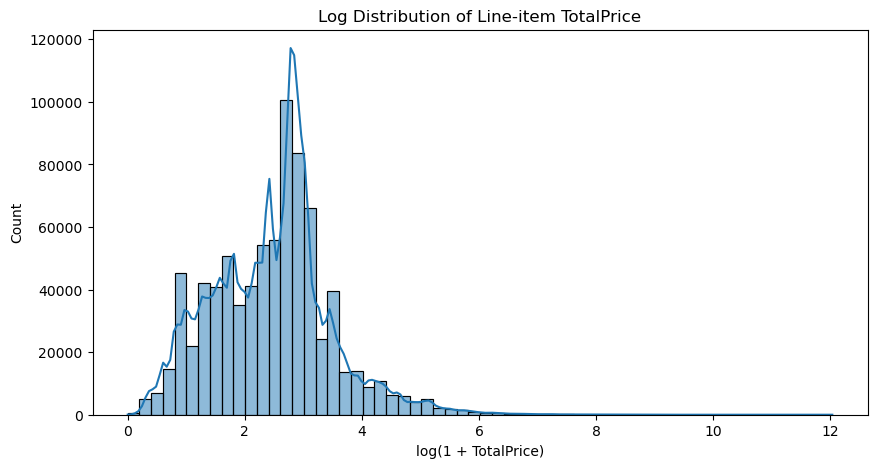

In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df_clean['TotalPrice']), bins=60, kde=True)
plt.title('Log Distribution of Line-item TotalPrice')
plt.xlabel('log(1 + TotalPrice)')
plt.show()

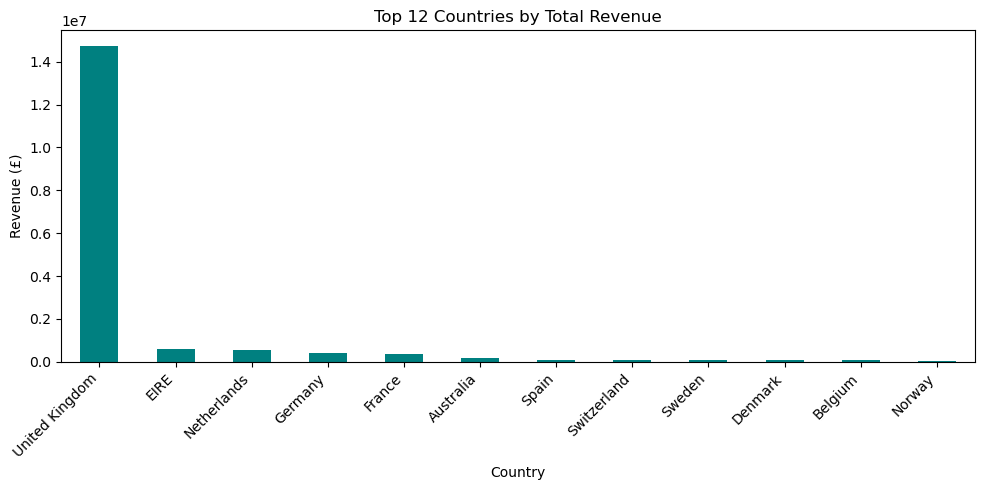

In [36]:
#Top 10 countries by revenue
top_countries = (
    df_clean.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 5))
top_countries.plot(kind='bar', color='teal')
plt.title('Top 12 Countries by Total Revenue')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

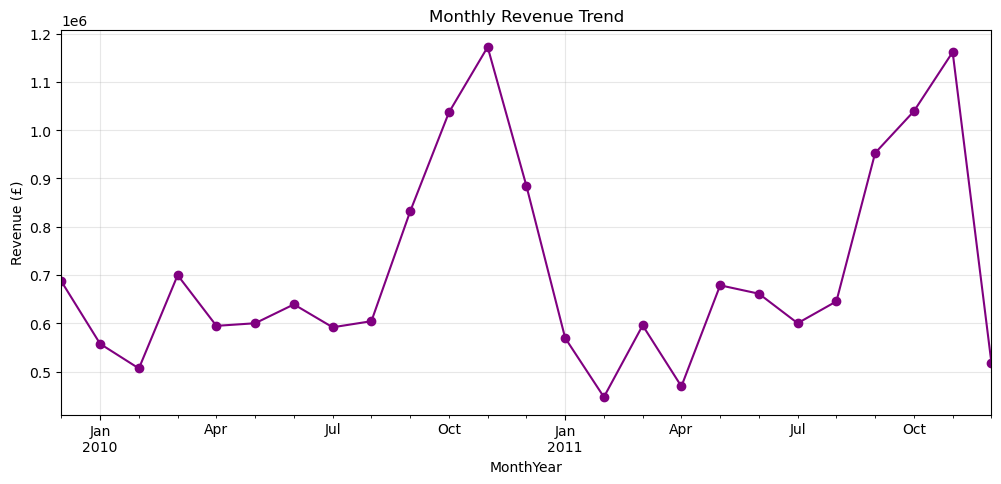

In [37]:
#Monthly revenue trend
monthly_revenue = df_clean.groupby('MonthYear')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
#Save cleaned data for next steps
df_clean.to_csv('../data/online_retail_cleaned.csv', index=False)
print("\nCleaned dataset saved → ../data/online_retail_cleaned.csv")


Cleaned dataset saved → ../data/online_retail_cleaned.csv
